In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Estilo visual
plt.style.use("ggplot")

print("✅ Setup listo")

✅ Setup listo


In [2]:
df = pd.read_csv("../data/processed/ventas_historico.csv")

# Convertir a datetime (por seguridad)
df["fecha"] = pd.to_datetime(df["fecha"])

df["fecha"] = pd.to_datetime(df["fecha"])

ultima_fecha = df["fecha"].max()

print(f"📊 Dataset actualizado hasta el {ultima_fecha.strftime('%d/%m/%Y')} | Registros: {len(df)}")

📊 Dataset actualizado hasta el 16/07/2026 | Registros: 11117


In [3]:
# KPIs principales
kpi_total_ventas = df["ventas"].sum()
kpi_prom_venta = df["ventas"].mean()
kpi_dias = df["fecha"].nunique()
kpi_registros = len(df)

# KPI: % ventas sobre promedio (si existe la columna)
if "venta_sobre_prom_producto" in df.columns:
    kpi_pct_sobre_prom = df["venta_sobre_prom_producto"].mean()
else:
    kpi_pct_sobre_prom = np.nan

print("📌 KPIs principales")
print(f"• Total ventas: {kpi_total_ventas:,.0f}")
print(f"• Promedio por registro: {kpi_prom_venta:,.2f}")
print(f"• Días en histórico: {kpi_dias}")
print(f"• Registros: {kpi_registros:,}")
if not np.isnan(kpi_pct_sobre_prom):
    print(f"• % ventas sobre promedio (producto): {kpi_pct_sobre_prom:.1%}")


📌 KPIs principales
• Total ventas: 13,925,975
• Promedio por registro: 1,252.67
• Días en histórico: 56
• Registros: 11,117
• % ventas sobre promedio (producto): 49.9%


In [4]:
# Ventas por producto / región
ventas_producto = df.groupby("producto")["ventas"].sum().sort_values(ascending=False)
ventas_region = df.groupby("region")["ventas"].sum().sort_values(ascending=False)

# Tendencia diaria
ventas_dia = df.groupby("fecha")["ventas"].sum().sort_index()

# KPI de performance: % sobre promedio por producto (si existe)
pct_sobre_prod = None
if "venta_sobre_prom_producto" in df.columns:
    pct_sobre_prod = df.groupby("producto")["venta_sobre_prom_producto"].mean().sort_values(ascending=False)

ventas_producto, ventas_region, ventas_dia.head()

(producto
 B    4724826
 C    4651728
 A    4549421
 Name: ventas, dtype: int64,
 region
 Sur       4681729
 Norte     4625371
 Centro    4618875
 Name: ventas, dtype: int64,
 fecha
 2026-05-19    248134
 2026-05-20    252314
 2026-05-21    248198
 2026-05-22    251652
 2026-05-23    245181
 Name: ventas, dtype: int64)

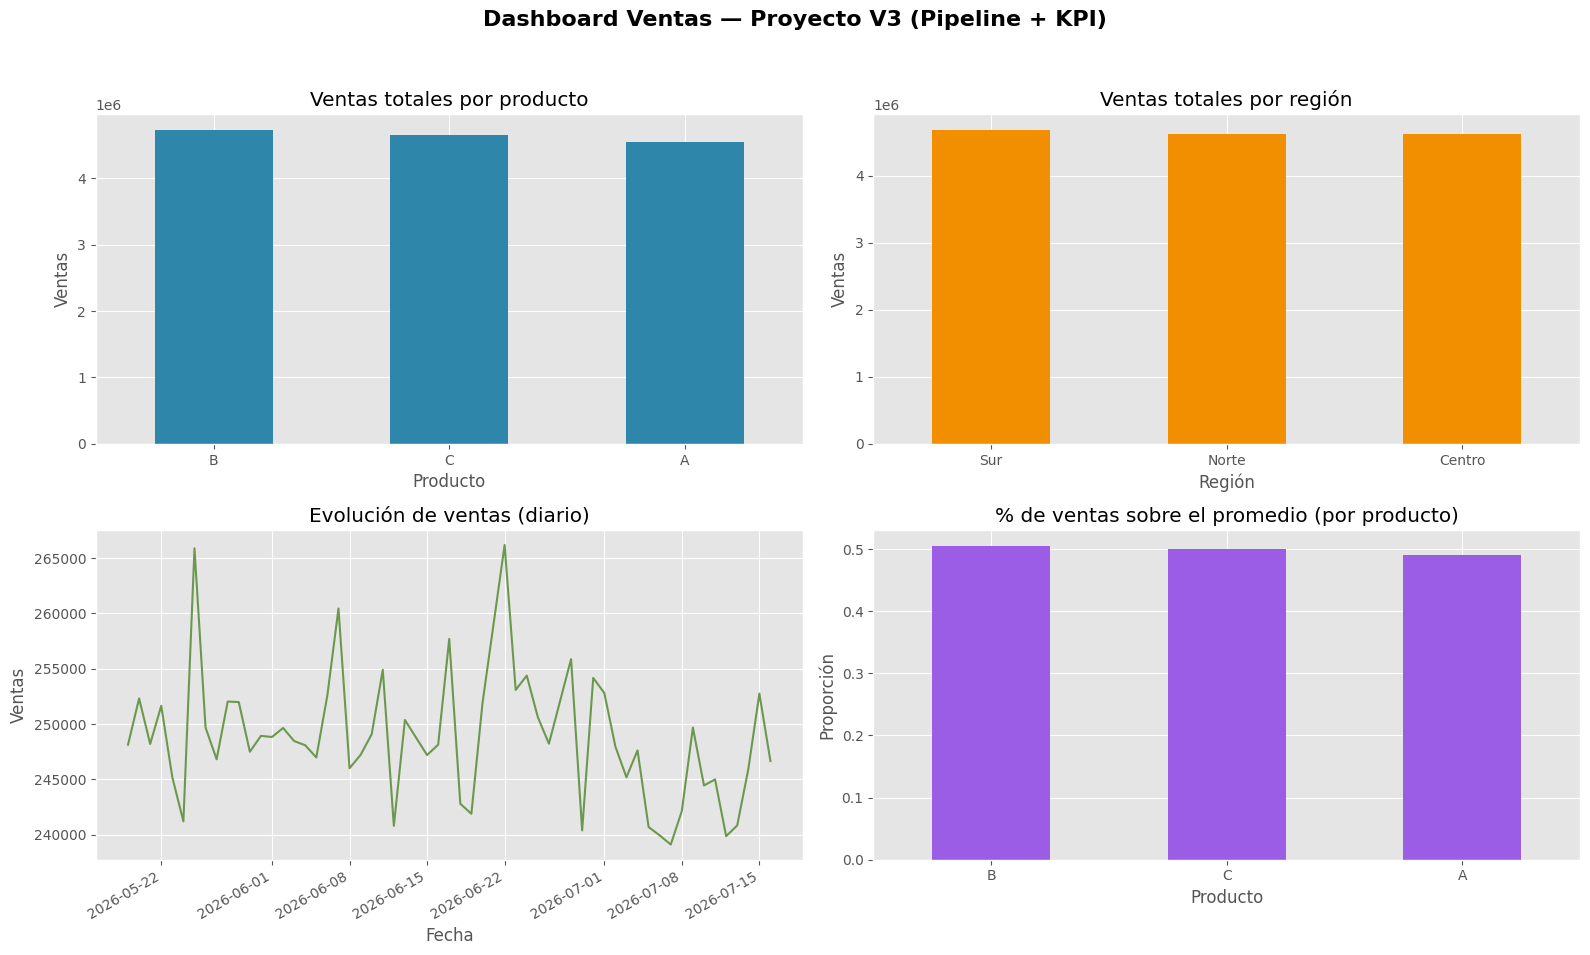

In [5]:
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Dashboard Ventas — Proyecto V3 (Pipeline + KPI)", fontsize=16, fontweight="bold")

# 1) Ventas por producto
ventas_producto.plot(kind="bar", ax=axs[0, 0], color="#2E86AB")
axs[0, 0].set_title("Ventas totales por producto")
axs[0, 0].set_xlabel("Producto")
axs[0, 0].set_ylabel("Ventas")
axs[0, 0].tick_params(axis="x", rotation=0)

# 2) Ventas por región
ventas_region.plot(kind="bar", ax=axs[0, 1], color="#F18F01")
axs[0, 1].set_title("Ventas totales por región")
axs[0, 1].set_xlabel("Región")
axs[0, 1].set_ylabel("Ventas")
axs[0, 1].tick_params(axis="x", rotation=0)

# 3) Tendencia diaria
ventas_dia.plot(ax=axs[1, 0], color="#6A994E")
axs[1, 0].set_title("Evolución de ventas (diario)")
axs[1, 0].set_xlabel("Fecha")
axs[1, 0].set_ylabel("Ventas")

# 4) % sobre promedio por producto (si existe)
axs[1, 1].axis("off")
if pct_sobre_prod is not None:
    axs[1, 1].axis("on")
    pct_sobre_prod.plot(kind="bar", ax=axs[1, 1], color="#9B5DE5")
    axs[1, 1].set_title("% de ventas sobre el promedio (por producto)")
    axs[1, 1].set_xlabel("Producto")
    axs[1, 1].set_ylabel("Proporción")
    axs[1, 1].tick_params(axis="x", rotation=0)
else:
    axs[1, 1].text(0.1, 0.5, "No existe columna 'venta_sobre_prom_producto'\n(Generá KPIs y volvemos a graficar).",
                   fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [6]:
top_prod = ventas_producto.index[0]
top_prod_val = ventas_producto.iloc[0]

top_reg = ventas_region.index[0]
top_reg_val = ventas_region.iloc[0]

ultimo_dia = ventas_dia.index.max()
ventas_ultimo = ventas_dia.loc[ultimo_dia]

print("🧠 Insights rápidos (auto)")
print(f"• Producto líder por ventas: {top_prod} ({top_prod_val:,.0f})")
print(f"• Región líder por ventas: {top_reg} ({top_reg_val:,.0f})")
print(f"• Ventas del último día ({ultimo_dia.date()}): {ventas_ultimo:,.0f}")

if pct_sobre_prod is not None:
    best_perf = pct_sobre_prod.index[0]
    best_perf_val = pct_sobre_prod.iloc[0]
    print(f"• Mejor performance relativa (% sobre promedio): {best_perf} ({best_perf_val:.1%})")

🧠 Insights rápidos (auto)
• Producto líder por ventas: B (4,724,826)
• Región líder por ventas: Sur (4,681,729)
• Ventas del último día (2026-07-16): 246,650
• Mejor performance relativa (% sobre promedio): B (50.6%)


In [8]:
from pathlib import Path

ruta = Path("../data/processed/ventas_historico.csv")
df = pd.read_csv(ruta)

# Tipos
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Chequeos básicos
cols_necesarias = {"fecha", "region", "producto", "ventas"}
faltan = cols_necesarias - set(df.columns)
if faltan:
    raise ValueError(f"Faltan columnas en el histórico: {faltan}")

# Asegurar ventas numéricas
df["ventas"] = pd.to_numeric(df["ventas"], errors="coerce")

# Filtrar filas inválidas (portfolio-friendly: mejor que explote por NaN)
df = df.dropna(subset=["fecha", "ventas", "region", "producto"])

df.head()

,fecha,region,producto,ventas,promedio_producto,venta_sobre_prom_producto,promedio_region,venta_sobre_prom_region
0,2026-05-19,Centro,A,1813,1252.938860,True,1241.966927,True
1,2026-05-19,Sur,C,1290,1256.205239,True,1253.474967,True
2,2026-05-19,Centro,B,711,1248.962728,False,1241.966927,False
3,2026-05-19,Norte,C,1412,1256.205239,True,1262.727546,True
4,2026-05-19,Sur,C,1858,1256.205239,True,1253.474967,True


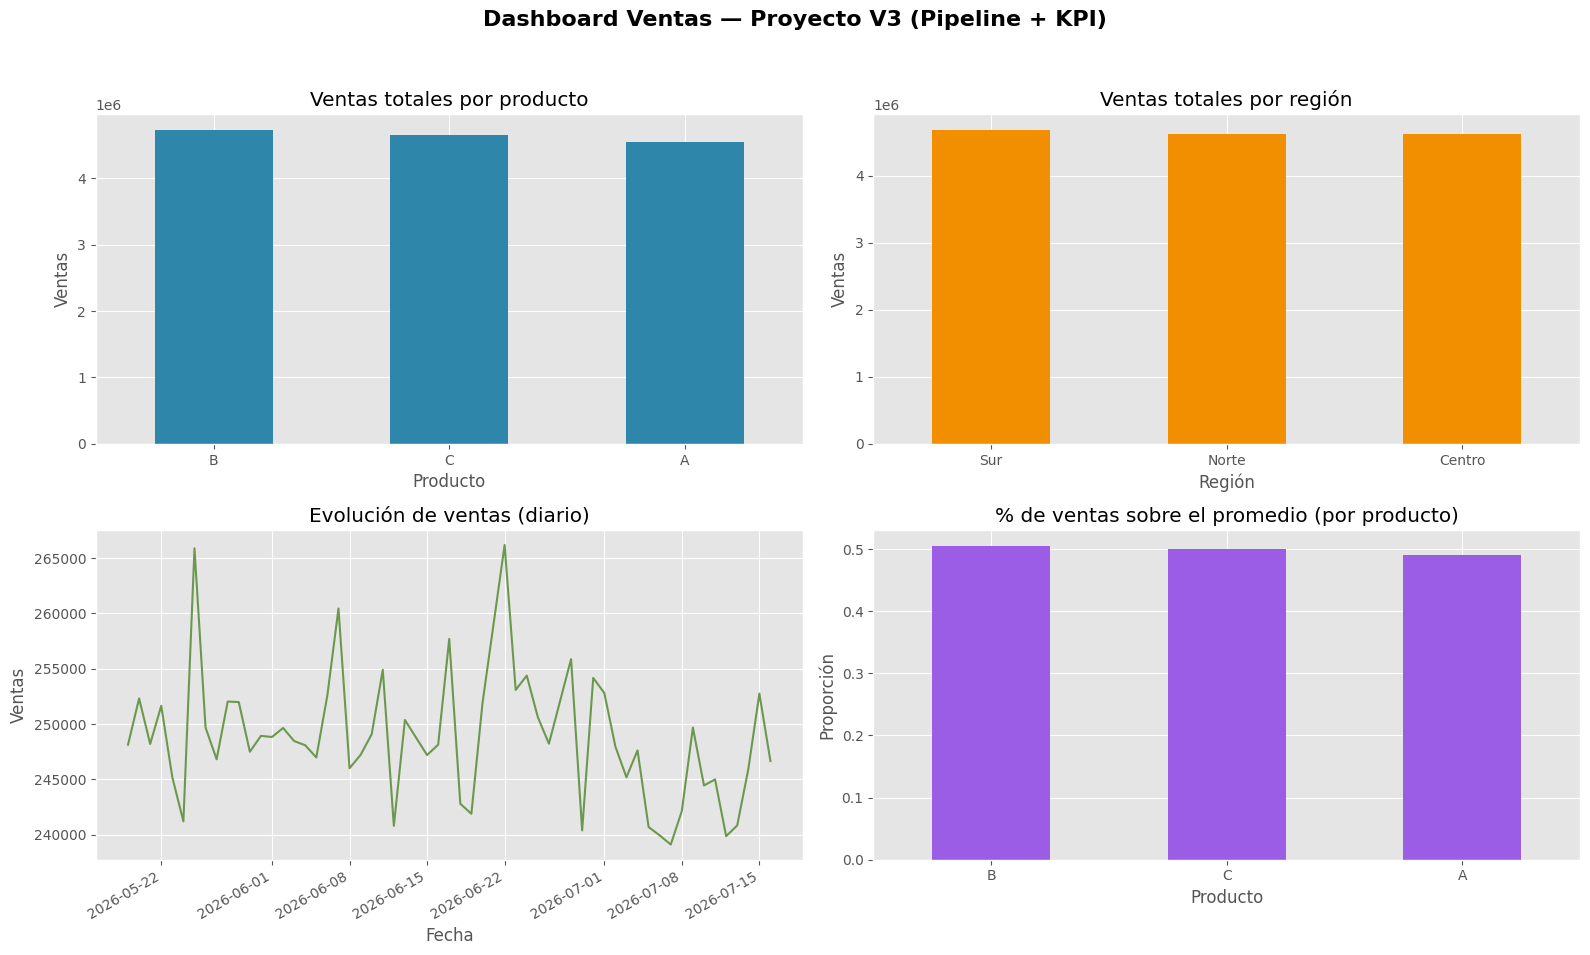

✅ Guardado: output/dashboard_v3.png


In [9]:
# Re-ejecuta el dashboard y guárdalo como PNG
fig, axs = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle("Dashboard Ventas — Proyecto V3 (Pipeline + KPI)", fontsize=16, fontweight="bold")

ventas_producto.plot(kind="bar", ax=axs[0, 0], color="#2E86AB")
axs[0, 0].set_title("Ventas totales por producto")
axs[0, 0].set_xlabel("Producto")
axs[0, 0].set_ylabel("Ventas")
axs[0, 0].tick_params(axis="x", rotation=0)

ventas_region.plot(kind="bar", ax=axs[0, 1], color="#F18F01")
axs[0, 1].set_title("Ventas totales por región")
axs[0, 1].set_xlabel("Región")
axs[0, 1].set_ylabel("Ventas")
axs[0, 1].tick_params(axis="x", rotation=0)

ventas_dia.plot(ax=axs[1, 0], color="#6A994E")
axs[1, 0].set_title("Evolución de ventas (diario)")
axs[1, 0].set_xlabel("Fecha")
axs[1, 0].set_ylabel("Ventas")

axs[1, 1].axis("off")
if pct_sobre_prod is not None:
    axs[1, 1].axis("on")
    pct_sobre_prod.plot(kind="bar", ax=axs[1, 1], color="#9B5DE5")
    axs[1, 1].set_title("% de ventas sobre el promedio (por producto)")
    axs[1, 1].set_xlabel("Producto")
    axs[1, 1].set_ylabel("Proporción")
    axs[1, 1].tick_params(axis="x", rotation=0)
else:
    axs[1, 1].text(0.1, 0.5, "Sin KPI 'venta_sobre_prom_producto'", fontsize=11)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Guardar
Path("../output").mkdir(exist_ok=True)
plt.savefig("../output/dashboard_v3.png", dpi=200)
plt.show()

print("✅ Guardado: output/dashboard_v3.png")

In [10]:
import sys
import os
sys.path.append("../src")

from generate_daily import generar_datos_dia

df_test = generar_datos_dia("2026-05-19")

df_test.head()

,fecha,region,producto,ventas
0,2026-05-19,Sur,B,1799
1,2026-05-19,Norte,B,1326
2,2026-05-19,Sur,C,1631
3,2026-05-19,Sur,B,1139
4,2026-05-19,Sur,A,1607


In [11]:
df = pd.read_csv("../data/processed/ventas_historico.csv")

In [12]:
import pandas as pd

df = pd.read_csv("../data/processed/ventas_historico.csv")

print("Filas y columnas:", df.shape)
print("Fecha mínima:", df["fecha"].min())
print("Fecha máxima:", df["fecha"].max())


Filas y columnas: (11117, 8)
Fecha mínima: 2026-05-19
Fecha máxima: 2026-07-16


In [13]:
import os
print(os.getcwd())


c:\Users\Usuario\OneDrive\Documentos\python_practica\analisis-ventas-python\notebooks


In [14]:
# ver estructura
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11117 entries, 0 to 11116
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   fecha                      11117 non-null  str    
 1   region                     11117 non-null  str    
 2   producto                   11117 non-null  str    
 3   ventas                     11117 non-null  int64  
 4   promedio_producto          11117 non-null  float64
 5   venta_sobre_prom_producto  11117 non-null  bool   
 6   promedio_region            11117 non-null  float64
 7   venta_sobre_prom_region    11117 non-null  bool   
dtypes: bool(2), float64(2), int64(1), str(3)
memory usage: 543.0 KB


In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["fecha"].value_counts()


fecha
2026-05-21    200
2026-05-24    200
2026-05-26    200
2026-05-30    200
2026-05-31    200
2026-06-03    200
2026-06-07    200
2026-06-08    200
2026-06-10    200
2026-06-13    200
2026-06-15    200
2026-06-17    200
2026-06-19    200
2026-06-24    200
2026-07-02    200
2026-07-03    200
2026-05-25    199
2026-06-06    199
2026-06-09    199
2026-06-20    199
2026-06-25    199
2026-06-28    199
2026-06-29    199
2026-07-04    199
2026-07-05    199
2026-07-10    199
2026-07-11    199
2026-07-13    199
2026-07-15    199
2026-05-19    198
2026-05-20    198
2026-05-22    198
2026-05-23    198
2026-05-27    198
2026-06-01    198
2026-06-02    198
2026-06-05    198
2026-06-12    198
2026-06-22    198
2026-06-23    198
2026-06-26    198
2026-07-01    198
2026-07-08    198
2026-07-14    198
2026-07-16    198
2026-06-04    197
2026-06-11    197
2026-06-16    197
2026-06-18    197
2026-06-30    197
2026-07-06    197
2026-07-07    197
2026-07-09    197
2026-05-28    196
2026-05-29    196
2026

In [17]:
df.groupby("producto")["venta_sobre_prom_producto"].mean()

producto
A    0.490774
B    0.505948
C    0.500945
Name: venta_sobre_prom_producto, dtype: float64

In [18]:
import pandas as pd

df = pd.read_csv("../data/processed/ventas_historico.csv")

print("Filas, columnas:", df.shape)
print("Min fecha:", df["fecha"].min())
print("Max fecha:", df["fecha"].max())

df.head()

Filas, columnas: (11117, 8)
Min fecha: 2026-05-19
Max fecha: 2026-07-16


,fecha,region,producto,ventas,promedio_producto,venta_sobre_prom_producto,promedio_region,venta_sobre_prom_region
0,2026-05-19,Centro,A,1813,1252.938860,True,1241.966927,True
1,2026-05-19,Sur,C,1290,1256.205239,True,1253.474967,True
2,2026-05-19,Centro,B,711,1248.962728,False,1241.966927,False
3,2026-05-19,Norte,C,1412,1256.205239,True,1262.727546,True
4,2026-05-19,Sur,C,1858,1256.205239,True,1253.474967,True


In [19]:
df.columns

Index(['fecha', 'region', 'producto', 'ventas', 'promedio_producto',
       'venta_sobre_prom_producto', 'promedio_region',
       'venta_sobre_prom_region'],
      dtype='str')

In [20]:
df[["producto","ventas","promedio_producto","venta_sobre_prom_producto"]].head(10)


,producto,ventas,promedio_producto,venta_sobre_prom_producto
0,A,1813,1252.938860,True
1,C,1290,1256.205239,True
2,B,711,1248.962728,False
3,C,1412,1256.205239,True
4,C,1858,1256.205239,True
5,B,667,1248.962728,False
6,C,1586,1256.205239,True
7,C,622,1256.205239,False
8,C,1137,1256.205239,False
9,A,1408,1252.938860,True


In [21]:
import pandas as pd

df = pd.read_csv("../data/processed/ventas_historico.csv")

df.head()

,fecha,region,producto,ventas,promedio_producto,venta_sobre_prom_producto,promedio_region,venta_sobre_prom_region
0,2026-05-19,Centro,A,1813,1252.938860,True,1241.966927,True
1,2026-05-19,Sur,C,1290,1256.205239,True,1253.474967,True
2,2026-05-19,Centro,B,711,1248.962728,False,1241.966927,False
3,2026-05-19,Norte,C,1412,1256.205239,True,1262.727546,True
4,2026-05-19,Sur,C,1858,1256.205239,True,1253.474967,True


In [83]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/processed/ventas_historico.csv")

# aseguramos formato de fecha
df["fecha"] = pd.to_datetime(df["fecha"])

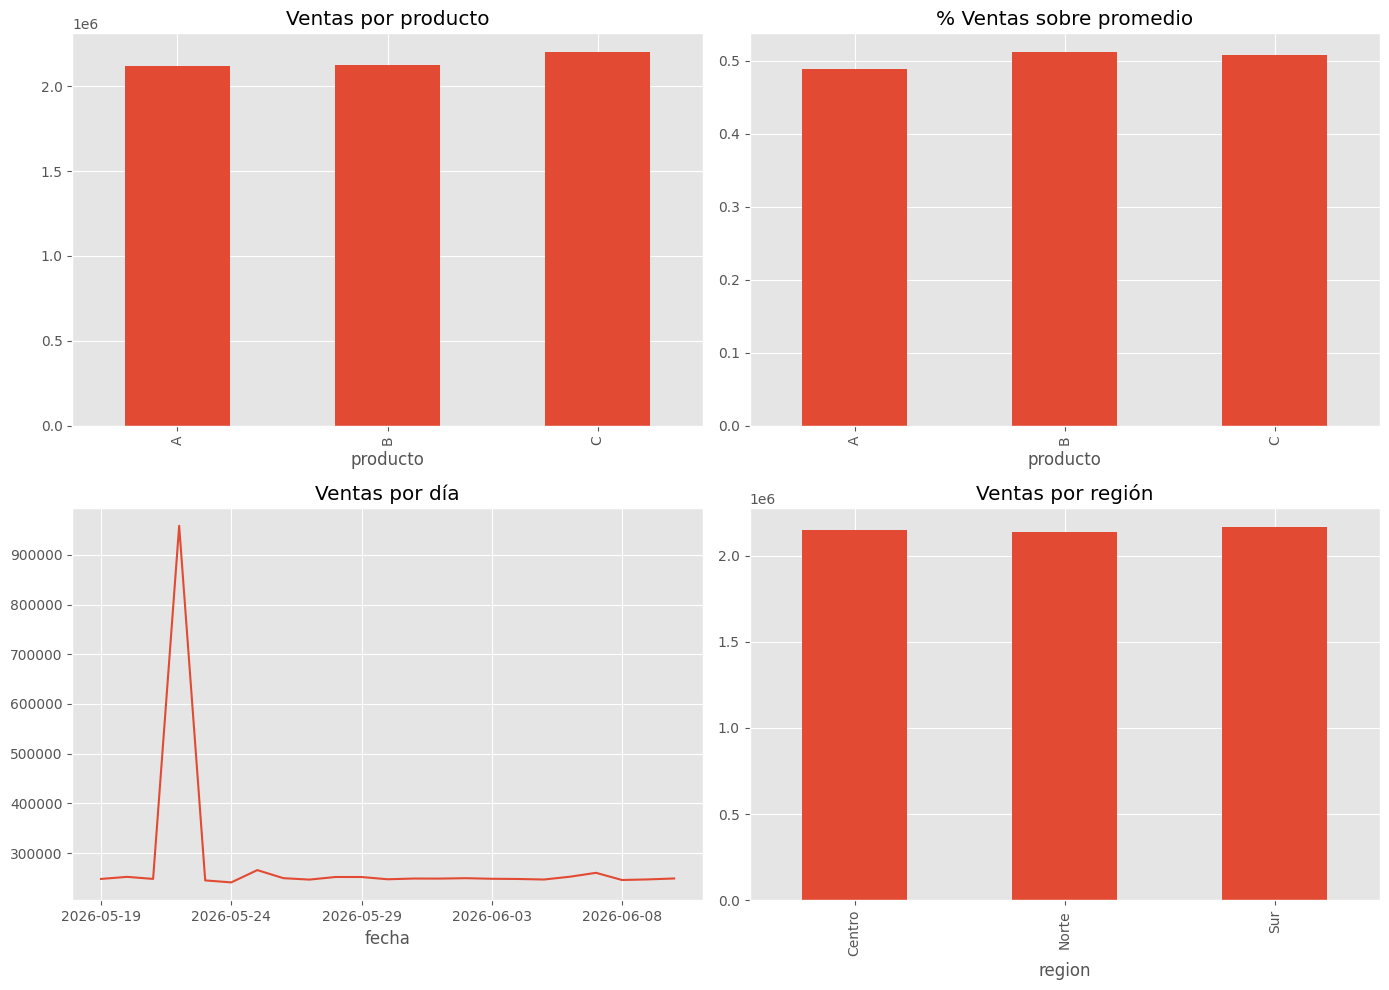

In [18]:
fig, axs = plt.subplots(2, 2, figsize=(14, 10))

plt.style.use("ggplot")

# 1. Ventas totales por producto
df.groupby("producto")["ventas"].sum().plot(
    kind="bar", ax=axs[0,0], title="Ventas por producto"
)

# 2. KPI: % ventas sobre promedio
df.groupby("producto")["venta_sobre_prom_producto"].mean().plot(
    kind="bar", ax=axs[0,1], title="% Ventas sobre promedio"
)

# 3. Ventas por día (tendencia)
df.groupby("fecha")["ventas"].sum().plot(
    ax=axs[1,0], title="Ventas por día"
)

# 4. Ventas por región
df.groupby("region")["ventas"].sum().plot(
    kind="bar", ax=axs[1,1], title="Ventas por región"
)

plt.tight_layout()
plt.show()

In [39]:
# Crear dataset modelo para Power BI
cols_modelo = [
    "fecha",
    "region",
    "producto",
    "ventas",
    "promedio_producto",
    "venta_sobre_prom_producto",
    "promedio_region",
    "venta_sobre_prom_region"
]

modelo = df[cols_modelo].copy()

# Guardar archivo
modelo.to_csv("../output/modelo_dashboard.csv", index=False)

print("✅ Archivo modelo_dashboard.csv generado")

✅ Archivo modelo_dashboard.csv generado


In [9]:
df = pd.read_csv(r"C:\Users\Usuario\OneDrive\Documentos\python_practica\analisis-ventas-python\data\processed\ventas_historico.csv")

In [10]:
import os
print(os.getcwd())

c:\Users\Usuario\OneDrive\Documentos\python_practica\analisis-ventas-python\notebooks


In [11]:
print(os.listdir())

['dashboard_ventas_v3.ipynb']


In [12]:
import os

print("Estoy parado en:")
print(os.getcwd())

print("\nContenido de la carpeta actual:")
print(os.listdir())

Estoy parado en:
c:\Users\Usuario\OneDrive\Documentos\python_practica\analisis-ventas-python\notebooks

Contenido de la carpeta actual:
['dashboard_ventas_v3.ipynb']


In [13]:
import os

os.chdir("..")

print("Nueva ubicación:")
print(os.getcwd())

print("\nContenido:")
print(os.listdir())

Nueva ubicación:
c:\Users\Usuario\OneDrive\Documentos\python_practica\analisis-ventas-python

Contenido:
['.git', '.gitignore', 'assets', 'data', 'logs', 'notebooks', 'output', 'README.md', 'run_pipeline.py', 'src', 'test_scheduler.txt']


In [17]:
import pandas as pd

df = pd.read_csv("data/processed/ventas_historico.csv")

df["fecha"] = pd.to_datetime(df["fecha"])

print(df.head())

       fecha  region producto  ventas  promedio_producto  \
0 2026-05-19  Centro        A    1813        1250.077963   
1 2026-05-19     Sur        C    1290        1250.844813   
2 2026-05-19  Centro        B     711        1259.137900   
3 2026-05-19   Norte        C    1412        1250.844813   
4 2026-05-19     Sur        C    1858        1250.844813   

   venta_sobre_prom_producto  promedio_region  venta_sobre_prom_region  
0                       True      1246.401679                     True  
1                       True      1258.676169                     True  
2                      False      1246.401679                    False  
3                       True      1254.969874                     True  
4                       True      1258.676169                     True  


In [18]:
conteo_por_dia = df.groupby("fecha").size()

print(conteo_por_dia)

fecha
2026-05-19    198
2026-05-20    198
2026-05-21    200
2026-05-22    771
2026-05-23    198
2026-05-24    200
2026-05-25    199
2026-05-26    200
2026-05-27    198
2026-05-28    196
2026-05-29    196
2026-05-30    200
2026-05-31    200
2026-06-01    198
2026-06-02    198
2026-06-03    200
2026-06-04    197
2026-06-05    198
2026-06-06    199
2026-06-07    200
2026-06-08    200
2026-06-09    199
2026-06-10    200
2026-06-11    197
2026-06-12    198
2026-06-13    200
2026-06-15    200
2026-06-16    197
2026-06-17    200
2026-06-18    197
2026-06-19    200
dtype: int64


In [16]:
# eliminar duplicados
df_clean = df.drop_duplicates(subset=["fecha", "region", "producto", "ventas"])

print("Filas antes:", len(df))
print("Filas después:", len(df_clean))


Filas antes: 6732
Filas después: 6732


In [19]:
# Filtrar solo el 22-05
df_22 = df[df["fecha"] == "2026-05-22"]

# Contar cuántas veces aparece cada combinación
conteo = df_22.groupby(["region", "producto"]).size().sort_values(ascending=False)

print("Cantidad de registros por combinación (region-producto):")
print(conteo.head(10))

Cantidad de registros por combinación (region-producto):
region  producto
Norte   A           100
        C            99
Centro  A            92
        C            91
        B            90
Sur     C            82
Norte   B            75
Sur     A            73
        B            69
dtype: int64


In [20]:
# Filtrar solo el 22-05
df_22 = df[df["fecha"] == "2026-05-22"]

# Total de filas ese día
print("Total filas 22-05:", len(df_22))

# Cantidad de combinaciones únicas (region-producto)
combinaciones_unicas = df_22.groupby(["region", "producto"]).ngroups

print("Combinaciones únicas region-producto:", combinaciones_unicas)


Total filas 22-05: 771
Combinaciones únicas region-producto: 9


In [21]:
# Filtrar solo el día problemático
df_22 = df[df["fecha"] == "2026-05-22"]

# Contar repeticiones por combinación
repeticiones = (
    df_22.groupby(["region", "producto"])
    .size()
    .sort_values(ascending=False)
)

print("Repeticiones por combinación (region-producto):")
print(repeticiones)

Repeticiones por combinación (region-producto):
region  producto
Norte   A           100
        C            99
Centro  A            92
        C            91
        B            90
Sur     C            82
Norte   B            75
Sur     A            73
        B            69
dtype: int64


In [22]:
repeticiones_df = repeticiones.reset_index(name="cantidad")

print(repeticiones_df)


   region producto  cantidad
0   Norte        A       100
1   Norte        C        99
2  Centro        A        92
3  Centro        C        91
4  Centro        B        90
5     Sur        C        82
6   Norte        B        75
7     Sur        A        73
8     Sur        B        69


In [23]:
import pandas as pd

# Cargar histórico actual
df = pd.read_csv("data/processed/ventas_historico.csv")
df["fecha"] = pd.to_datetime(df["fecha"], errors="coerce")

# Backup
df.to_csv("data/processed/ventas_historico_backup_antes_fix_22052026.csv", index=False)

print("Backup generado OK")

Backup generado OK


In [24]:
df_fuente_22 = pd.read_csv("data/raw/ventas_2026-05-22.csv")
df_fuente_22["fecha"] = pd.to_datetime(df_fuente_22["fecha"], errors="coerce")

print("Filas fuente 22/05:", len(df_fuente_22))
print(df_fuente_22.head())

Filas fuente 22/05: 200
       fecha  region producto  ventas
0 2026-05-22  Centro        A    1564
1 2026-05-22   Norte        C    1884
2 2026-05-22     Sur        A    1712
3 2026-05-22   Norte        C    1040
4 2026-05-22   Norte        A     681


In [25]:
df_sin_22 = df[df["fecha"] != "2026-05-22"].copy()

print("Filas histórico sin 22/05:", len(df_sin_22))

Filas histórico sin 22/05: 5961


In [26]:
df_rearmado = pd.concat([df_sin_22[["fecha", "region", "producto", "ventas"]],
                         df_fuente_22[["fecha", "region", "producto", "ventas"]]],
                        ignore_index=True)

print("Filas rearmadas:", len(df_rearmado))

Filas rearmadas: 6161


In [27]:
# Promedios por producto
prom_prod = (
    df_rearmado.groupby("producto")["ventas"]
    .mean()
    .rename("promedio_producto")
)

# Promedios por región
prom_reg = (
    df_rearmado.groupby("region")["ventas"]
    .mean()
    .rename("promedio_region")
)

# Merge de promedios
df_final = df_rearmado.merge(prom_prod, on="producto", how="left")
df_final = df_final.merge(prom_reg, on="region", how="left")

# Flags
df_final["venta_sobre_prom_producto"] = df_final["ventas"] > df_final["promedio_producto"]
df_final["venta_sobre_prom_region"] = df_final["ventas"] > df_final["promedio_region"]

print(df_final.head())

       fecha  region producto  ventas  promedio_producto  promedio_region  \
0 2026-05-19  Centro        A    1813        1251.313116      1245.774600   
1 2026-05-19     Sur        C    1290        1253.244615      1258.697776   
2 2026-05-19  Centro        B     711        1261.032779      1245.774600   
3 2026-05-19   Norte        C    1412        1253.244615      1261.193103   
4 2026-05-19     Sur        C    1858        1253.244615      1258.697776   

   venta_sobre_prom_producto  venta_sobre_prom_region  
0                       True                     True  
1                       True                     True  
2                      False                    False  
3                       True                     True  
4                       True                     True  


In [28]:
# Verificar conteo de filas por día
conteo_por_dia_final = df_final.groupby("fecha").size().sort_index()

print("Conteo por día:")
print(conteo_por_dia_final)

# Verificar ventas por día (foco en fechas cercanas)
ventas_por_dia_final = df_final.groupby("fecha")["ventas"].sum().sort_index()

print("\nVentas por día (22/05 vs días cercanos):")
print(ventas_por_dia_final.loc["2026-05-20":"2026-05-24"])

Conteo por día:
fecha
2026-05-19    198
2026-05-20    198
2026-05-21    200
2026-05-22    200
2026-05-23    198
2026-05-24    200
2026-05-25    199
2026-05-26    200
2026-05-27    198
2026-05-28    196
2026-05-29    196
2026-05-30    200
2026-05-31    200
2026-06-01    198
2026-06-02    198
2026-06-03    200
2026-06-04    197
2026-06-05    198
2026-06-06    199
2026-06-07    200
2026-06-08    200
2026-06-09    199
2026-06-10    200
2026-06-11    197
2026-06-12    198
2026-06-13    200
2026-06-15    200
2026-06-16    197
2026-06-17    200
2026-06-18    197
2026-06-19    200
dtype: int64

Ventas por día (22/05 vs días cercanos):
fecha
2026-05-20    252314
2026-05-21    248198
2026-05-22    254248
2026-05-23    245181
2026-05-24    241197
Name: ventas, dtype: int64


In [29]:
df_final.to_csv("data/processed/ventas_historico.csv", index=False)

print("Histórico corregido guardado OK")

Histórico corregido guardado OK


In [30]:
import pandas as pd

df_check = pd.read_csv("data/processed/ventas_historico.csv")
df_check["fecha"] = pd.to_datetime(df_check["fecha"], errors="coerce")

print(df_check.groupby("fecha").size().loc["2026-05-20":"2026-05-24"])
print(df_check.groupby("fecha")["ventas"].sum().loc["2026-05-20":"2026-05-24"])

fecha
2026-05-20    198
2026-05-21    200
2026-05-22    198
2026-05-23    198
2026-05-24    200
dtype: int64
fecha
2026-05-20    252314
2026-05-21    248198
2026-05-22    251652
2026-05-23    245181
2026-05-24    241197
Name: ventas, dtype: int64


In [31]:
import pandas as pd

df_check = pd.read_csv("data/processed/ventas_historico.csv")
df_check["fecha"] = pd.to_datetime(df_check["fecha"], errors="coerce")

print(df_check.groupby("fecha").size().tail(10))

fecha
2026-06-09    199
2026-06-10    200
2026-06-11    197
2026-06-12    198
2026-06-13    200
2026-06-15    200
2026-06-16    197
2026-06-17    200
2026-06-18    197
2026-06-19    200
dtype: int64
